In [18]:
import zipfile

zip_path = "/content/data.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Start by making the necessary imports

In [19]:
import tensorflow as tf

import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [20]:
img = cv2.imread("data/train/angry/Training_3908.jpg")

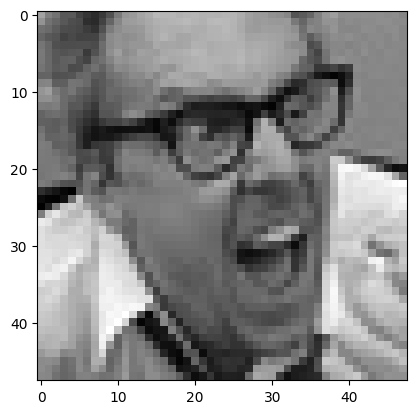

In [21]:
plt.imshow(img)

We can tell that this does work as teh image does load perfectly

In [22]:
Datadirectory = "data/train"
Classes = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

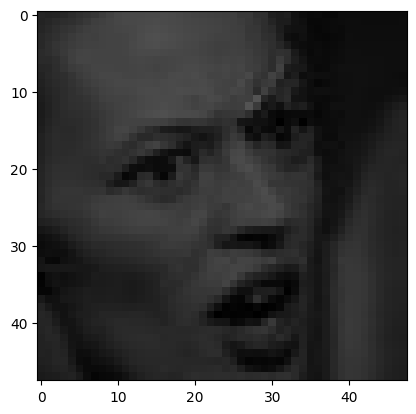

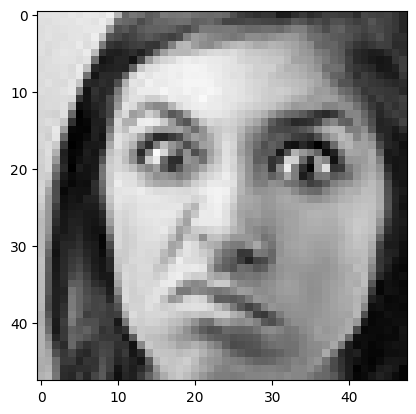

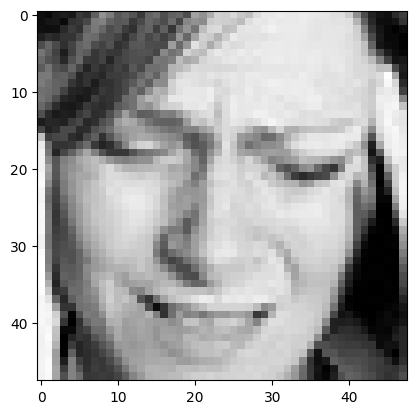

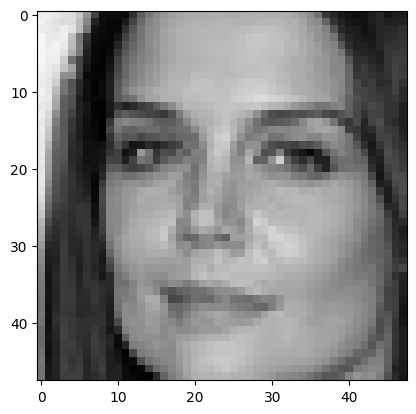

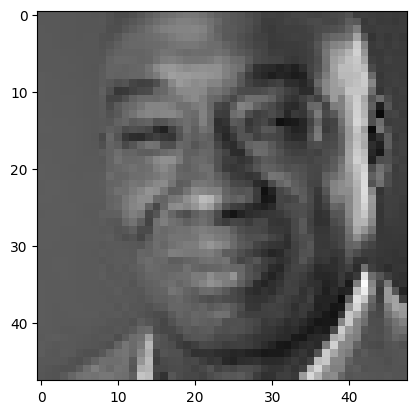

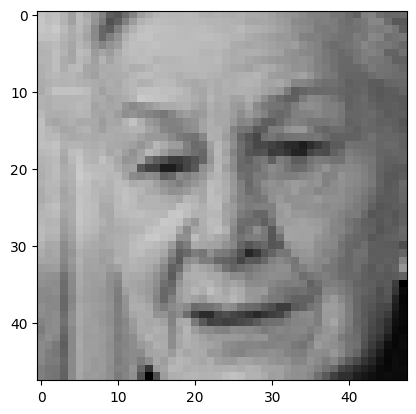

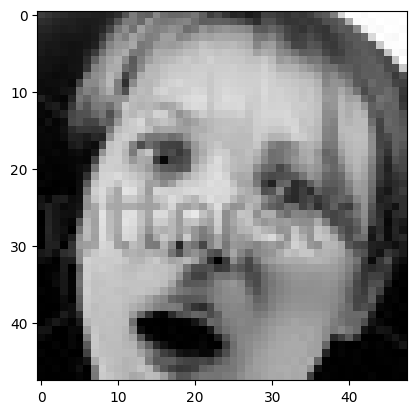

In [23]:
for category in Classes:
    path = os.path.join(Datadirectory, category)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img))
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.show()
        break

lets try rescaling this so it works with our pre trained structure of code

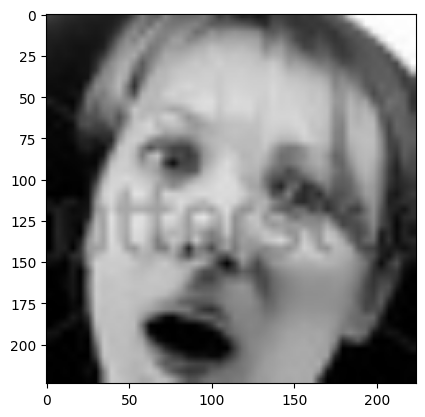

In [24]:
img_size = 224
new_array = cv2.resize(img_array, (img_size, img_size))
plt.imshow(cv2.cvtColor(new_array, cv2.COLOR_BGR2RGB))
plt.show()

# Read all the images and convert into array

In [25]:
training_Data = []
def create_training_Data():
    for category in Classes:
        path = os.path.join(Datadirectory, category)
        class_num = Classes.index(category)
        for i in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, i))
                new_array = cv2.resize(img_array, (img_size, img_size))
                training_Data.append([new_array, class_num])
            except Exception as e:
                pass



In [26]:
create_training_Data()

In [27]:
print(len(training_Data))

28709


# Add random shuffling feature so that it doenst memorize the whole order of the images each time

In [28]:
import random
random.shuffle(training_Data)

In [29]:
X = []
y = []
for features,labels in training_Data:
    X.append(features)
    y.append(labels)
X = np.array(X).reshape(-1, img_size, img_size, 3)

In [30]:
X.shape

(28709, 224, 224, 3)

# Normalize the data

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("Loading the image generators...")

# 1. Create the tools that will read your images and apply the MobileNetV2 (-1 to 1) math
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 2. Tell the generators exactly where your unzipped folders are
train_generator = train_datagen.flow_from_directory(
    '/content/data/train', # Make sure this matches your extracted folder path!
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    '/content/data/test', # Make sure this matches your extracted folder path!
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Loading the image generators...
Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Generators loaded successfully! You can now calculate the weights.


In [ ]:
#Extract the classes from the training data
train_classes = train_generator.classes

# Calculate the mathematical weights to balance the dataset
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),

    
    y=train_classes
)

# Convert to a dictionary format for Keras
class_weight_dict = dict(enumerate(class_weights))


print("Class Weights Calculated successfully:")
for emotion, weight in zip(train_generator.class_indices.keys(), class_weights):
    print(f"{emotion}: {weight:.2f}")

Class Weights Calculated successfully:
angry: 1.03
disgust: 9.41
fear: 1.00
happy: 0.57
neutral: 0.83
sad: 0.85
surprise: 1.29


## TRANSFER LEARNING SECTION NOW

In [34]:
from tensorflow.keras.applications import MobileNetV2 # Or whatever you were using (ResNet, VGG)
from tensorflow.keras import layers, models

# 1. Load the pre-trained brain
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. THE FIX: Unfreeze the brain!
base_model.trainable = True

# 3. Freeze the first 100 base layers (keep basic shape detection), but let the top layers learn faces
for layer in base_model.layers[:100]:
    layer.trainable = False

# 4. Snap your custom emotion-guessing layers on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # This prevents the AI from just memorizing the pictures
    layers.Dense(7, activation='softmax') # Your 7 emotions
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 2,191,175 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [36]:

base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

# Lets compile the model with a VERY SMALL learning rate (0.0001)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Base model unfrozen and recompiled for fine-tuning!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 2,191,175 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

## USE WITH CAUTION AS IT CAN TAKE UPTO 30 MINUTES FOR IT TO BE FULLY DONE NOW.
### IT IS HIGHLY RECOMMENDED TO RUN THIS IN THE COLAB IF YOU DO NOT HAVE A POWERFUL MACHINE WITH ATLEAST 16GB RAM


In [37]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory('data/train', target_size=(224, 224), batch_size=32, class_mode='categorical')
validation_generator = test_datagen.flow_from_directory('data/test', target_size=(224, 224), batch_size=32, class_mode='categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
# These tools automatically save the best version and stop the training if it stops improving ( like iincreasing accuracy AND the loss functions value at the same time)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# This time i changed the .h5 file into the keras one which is the latest one used for saving these 
checkpoint = ModelCheckpoint("best_model_v2.keras", monitor='val_accuracy', save_best_only=True)

print("Starting the Fine-Tuning Marathon! This will take a while...")

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    class_weight=class_weight_dict, # THIS IS THE MAGIC BULLET
    callbacks=[early_stop, checkpoint]
)

Starting the Fine-Tuning Marathon! This will take a while...
Epoch 1/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 129s 106ms/step - accuracy: 0.3964 - loss: 1.5625 - val_accuracy: 0.3952 - val_loss: 1.6798
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.5511 - loss: 1.1483 - val_accuracy: 0.4969 - val_loss: 1.3932
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 59ms/step - accuracy: 0.6253 - loss: 0.9177 - val_accuracy: 0.5904 - val_loss: 1.1080
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 52s 58ms/step - accuracy: 0.6835 - loss: 0.7620 - val_accuracy: 0.5979 - val_loss: 1.1454
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - accuracy: 0.7426 - loss: 0.6354 - val_accuracy: 0.5623 - val_loss: 1.3827
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 54s 60ms/step - accuracy: 0.7969 - loss: 0.5068 - val_accuracy: 0.5602 - val_loss: 1.6084
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 52s 58ms/step - accuracy: 0.8533 - loss: 0.3630 - val_accuracy: 0.5832 - val_loss: 1.5763
Epoch 8/50
898/898 ━━━━━━━━

In [39]:
# THE FIX: Changed the final backup save to .keras as well
model.save("best_model_backup.keras")
print("Model saved perfectly in the modern Keras format!")

Model saved perfectly in the modern Keras format!
